In [5]:
# training rough model

import numpy as np
from tensorflow.keras import layers, models
import tensorflow as tf


In [4]:
X_DIR = "../data/processed/patches/X.npy"
Y_DIR = "../data/processed/patches/Y.npy"

X = np.load(X_DIR).astype(np.float32)
Y = np.load(Y_DIR).astype(np.float32)

print("X shape:", X.shape, "dtype:", X.dtype, "min/max:", X.min(), X.max())
print("Y shape:", Y.shape, "dtype:", Y.dtype, "min/max:", Y.min(), Y.max())


X shape: (74, 256, 256, 1) dtype: float32 min/max: 0.0 1.0
Y shape: (74, 256, 256, 1) dtype: float32 min/max: 0.0 1.0


In [1]:
# simple unet model

def build_unet(input_shape=(256,256,1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.UpSampling2D()(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

In [6]:

def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model = build_unet()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=combined_loss,
              metrics=['accuracy'])

In [14]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=[dice_coef, iou_coef]
)

In [15]:
history = model.fit(
    X, Y,
    batch_size=4,
    epochs=20,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 264ms/step - dice_coef: 0.1739 - iou_coef: 0.0987 - loss: 1.5122 - val_dice_coef: 0.1746 - val_iou_coef: 0.0994 - val_loss: 1.4932
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - dice_coef: 0.1637 - iou_coef: 0.0923 - loss: 1.4749 - val_dice_coef: 0.1572 - val_iou_coef: 0.0880 - val_loss: 1.4310
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 244ms/step - dice_coef: 0.1344 - iou_coef: 0.0733 - loss: 1.3716 - val_dice_coef: 0.0926 - val_iou_coef: 0.0491 - val_loss: 1.3952
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 236ms/step - dice_coef: 0.1064 - iou_coef: 0.0568 - loss: 1.3397 - val_dice_coef: 0.1096 - val_iou_coef: 0.0589 - val_loss: 1.3726
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - dice_coef: 0.1180 - iou_coef: 0.0638 - loss: 1.3288 - val_dice_coef: 0.1095 - val_iou_coef: 0.0588 - val_loss: 1.3589
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - dice_coef: 0.1132 - iou_coef: 0.0606 - loss: 1.3111 - val_dice_coef: 0.1064 - val_iou_

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step


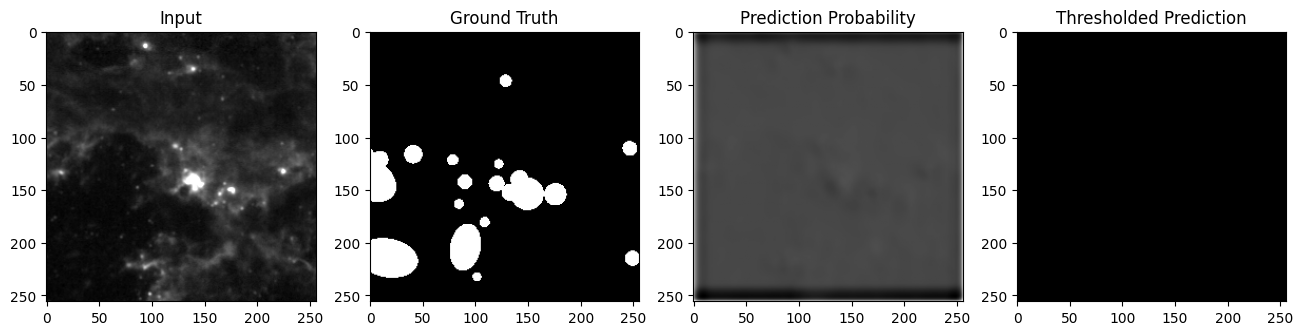

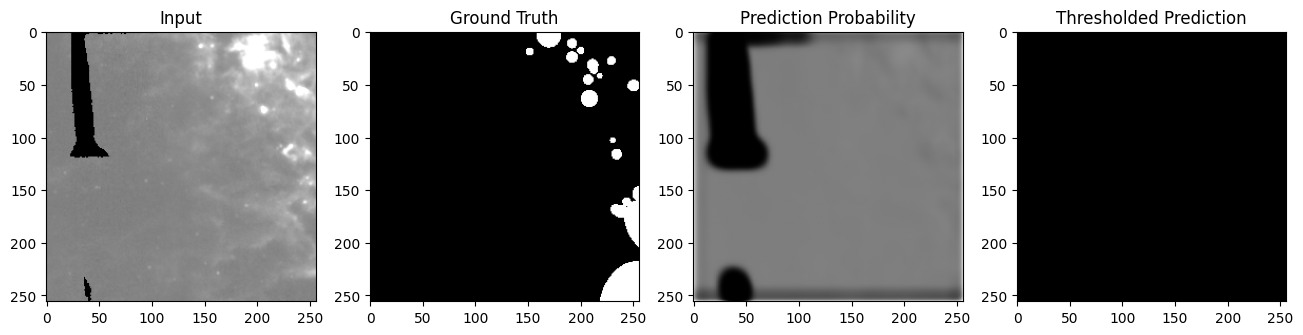

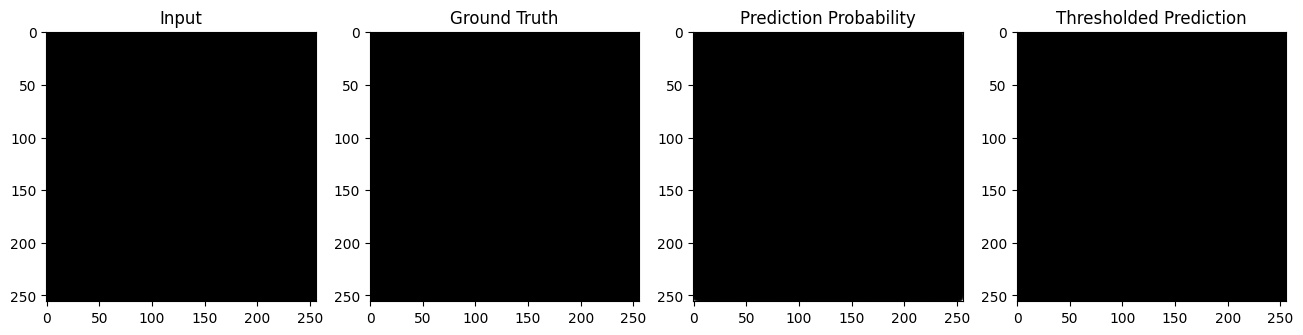

In [17]:
preds = model.predict(X)

for idx in [0, 5, 10]:
    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.title("Input")
    plt.imshow(X[idx].squeeze(), cmap="gray")

    plt.subplot(1,4,2)
    plt.title("Ground Truth")
    plt.imshow(Y[idx].squeeze(), cmap="gray")

    plt.subplot(1,4,3)
    plt.title("Prediction Probability")
    plt.imshow(preds[idx].squeeze(), cmap="gray")

    plt.subplot(1,4,4)
    plt.title("Thresholded Prediction")
    plt.imshow(preds[idx].squeeze() > 0.5, cmap="gray")

    plt.show()

In [18]:
print("Foreground pixel ratio:", np.mean(Y))
print("Background pixel ratio:", 1 - np.mean(Y))
print("Prediction min:", preds.min())
print("Prediction max:", preds.max())
print("Prediction mean:", preds.mean())

Foreground pixel ratio: 0.11603876
Background pixel ratio: 0.88396126
Prediction min: 1.372716e-12
Prediction max: 0.42896962
Prediction mean: 0.16409257
